### Feature Engineering = Deriving new features from existing onces

##### For SpaceDebrisRadar.AI using the primary orbital parameters, we get an easy way to derive such features.
-----

We will derive following features with scientific/mathematical methods

1. Orbit height (h) :
- Describes how high a satellite is above Earth.
- Used to identify orbit type
- Higher orbit = Low drag, more stable, less velocity
- Lower orbit = high drag, less stable, higher velocity

Method to derive -> Using Kepler's 3rd law  
$$
a = \left( \frac{\mu \, T^2}{4 \pi^2} \right)^{\frac{1}{3}}
$$

Where:  
- $a$ = semi-major axis (meters)  
- $\mu = 3.986 \times 10^{14} \, \mathrm{m^3/s^2}$ (Earth’s gravitational parameter)  
- $T$ = orbital period in seconds (computed as $T = \frac{86400}{\text{MEAN\_MOTION}}$)

##### So, we will need to derive first : 1. T (orbital perdiod in second)
----
2. Perigee and Apogee :
- Perigee = Closest point from satellite to Earth in its orbit
- Apogee = Farthest point from satellite to Earth in its orbit
- Helps to analyze orbital shape even clearer

Method to derive -> Using semi-major axis a and eccentricity e

Perigee = a × (1 - e)

Apogee = a × (1 + e)

Intuition: e measures how stretched the orbit is; multiplying by a gives the distance from Earth’s center at the closest/farthest points.

----
3. Orbit speed (v) :
- Describes how fast a satellite is moving .
- Nearer the perigee = higher speed
- Nearer the apogee = lower speed

Method to derive -> sing semi-major axis and radius (vis-viva equation)

Formula:

v = v ≈ sqrt(μ / a)

Where:

μ = Earth’s gravitational parameter

a = semi-major axis

----
4. Age since launch (Days) :


- **Definition:** Time elapsed between the satellite’s **launch date** and the **epoch date** of the current observation.
- **Formula (conceptual):**  
  $$\text{Age (days)} = \text{Epoch Date} - \text{Launch Date}$$
- **Why it matters:**  
  - Satellites degrade over time due to **orbital decay**, **space weather**, or **mechanical aging**.  
  - Useful for **anomaly detection** or understanding expected orbital behavior.
- **Units:** Typically **days**, but can also convert to **years** for readability.
- **Prototype use:** Can be added as a **numerical feature** for clustering or ML models.
----
5. Satellite Type

- **Definition:** The **type or sequence of the satellite** within a launch, extracted from the last character of the `OBJECT_ID`.  
- **How it’s extracted:**  
  - `OBJECT_ID` format: `YYYY-NNN[A-Z]`  
    - `YYYY` → launch year  
    - `NNN` → launch number of that year  
    - `[A-Z]` → satellite type / sequence (A = primary payload, B/C... = secondary payloads)  
- **Why it matters:**  
  - Satellites of the same launch can behave differently; primary payloads may have **different orbit characteristics** than secondary or experimental satellites.  
  - Useful as a **categorical feature** for clustering or anomaly detection.  
- **Prototype use:** Can be added as a **categorical feature** to help ML models distinguish satellite roles within the same launch.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Important thorughout this project
%matplotlib inline


In [34]:
df = pd.read_csv('../data/raw/gp.csv')

In [35]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,CALSPHERE 1,1964-063C,2025-10-05T10:37:28.191360,13.762289,0.002461,90.2163,65.8752,347.2003,74.9038,0,U,900,999,3638,0.001091,1.074000e-05,0.0
1,CALSPHERE 2,1964-063E,2025-10-05T11:04:00.444864,13.528741,0.001678,90.2292,69.7816,244.2673,178.7129,0,U,902,999,82182,0.000110,8.200000e-07,0.0
2,LCS 1,1965-034C,2025-10-05T12:08:01.406976,9.893092,0.001358,32.1425,61.7207,300.3713,59.5442,0,U,1361,999,18466,-0.001468,-3.000000e-08,0.0
3,TEMPSAT 1,1965-065E,2025-10-05T06:44:31.462944,13.335738,0.006776,89.9871,212.7305,243.9611,271.6250,0,U,1512,999,92607,0.000109,6.300000e-07,0.0
4,CALSPHERE 4A,1965-065H,2025-10-05T13:13:59.657952,13.362208,0.007127,89.9109,124.8412,101.8063,291.1203,0,U,1520,999,92870,0.000297,1.650000e-06,0.0


#### 1. Let's compute Orbit height (h) in Kilometers

- Compute orbital period in seconds
- It tells that in average, how much time (in seconds) does a satellite takes to orbit around the Earth

In [36]:
df['ORBIT_PERIOD_SEC'] = 86400 / df['MEAN_MOTION']

In [37]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC
0,CALSPHERE 1,1964-063C,2025-10-05T10:37:28.191360,13.762289,0.002461,90.2163,65.8752,347.2003,74.9038,0,U,900,999,3638,0.001091,1.074000e-05,0.0,6278.025279
1,CALSPHERE 2,1964-063E,2025-10-05T11:04:00.444864,13.528741,0.001678,90.2292,69.7816,244.2673,178.7129,0,U,902,999,82182,0.000110,8.200000e-07,0.0,6386.403631
2,LCS 1,1965-034C,2025-10-05T12:08:01.406976,9.893092,0.001358,32.1425,61.7207,300.3713,59.5442,0,U,1361,999,18466,-0.001468,-3.000000e-08,0.0,8733.366297
3,TEMPSAT 1,1965-065E,2025-10-05T06:44:31.462944,13.335738,0.006776,89.9871,212.7305,243.9611,271.6250,0,U,1512,999,92607,0.000109,6.300000e-07,0.0,6478.831324
4,CALSPHERE 4A,1965-065H,2025-10-05T13:13:59.657952,13.362208,0.007127,89.9109,124.8412,101.8063,291.1203,0,U,1520,999,92870,0.000297,1.650000e-06,0.0,6465.997033


 - Compute Earth’s gravitational parameter

In [38]:
# Gravitational constant (G) in N m^2/kg^2
G = 6.67430e-11 

# Mass of Earth (M_E) in kg
M_earth = 5.972e24 

# Calculate Earth's gravitational parameter in m^3/s^2
mu_earth_calculated = G * M_earth  # in meters

In [39]:
mu_earth_calculated

398589196000000.0

- Compute Semi major axis for each satelite (in KM)

In [40]:
df['SEMI_MAJOR_AXIS'] = ((mu_earth_calculated * df['ORBIT_PERIOD_SEC'] ** 2 ) / (4*math.pi**2)) **(1/3) / 1000

In [41]:
df['SEMI_MAJOR_AXIS']

0        7355.360594
1        7439.769906
2        9165.926686
3        7511.379609
4        7501.456514
            ...     
12791    7381.215260
12792    7380.611376
12793    7380.483130
12794    6967.236154
12795    6967.271239
Name: SEMI_MAJOR_AXIS, Length: 12796, dtype: float64

- Lastly, subtract semi mejor axis with Earth's radius to get orbital height (h)

In [42]:
df['ORBIT_HEIGHT'] = df['SEMI_MAJOR_AXIS'] -  6371

In [43]:
df['ORBIT_HEIGHT']

0         984.360594
1        1068.769906
2        2794.926686
3        1140.379609
4        1130.456514
            ...     
12791    1010.215260
12792    1009.611376
12793    1009.483130
12794     596.236154
12795     596.271239
Name: ORBIT_HEIGHT, Length: 12796, dtype: float64

In [44]:
df['ORBIT_HEIGHT'].describe()

count    12796.000000
mean      2550.482327
std       7981.835007
min        158.895750
25%        482.388235
50%        546.822224
75%        579.096142
max      91289.974838
Name: ORBIT_HEIGHT, dtype: float64

#### Since our project is about Low Earth Orbit, we can now easiy filter those satellites (orbital height >=160 & orbtial height <=2000)

In [45]:
# before row count : 
df.shape

(12796, 20)

In [46]:
df = df[(df['ORBIT_HEIGHT'] >=160) & (df['ORBIT_HEIGHT'] <=2000)]

In [47]:
df.shape

(11990, 20)

----
#### 2. Let's compute Perigee and Apogee

In [48]:
# Perigee = a * (1 - e) -> closest point

df['PERIGEE'] = df['SEMI_MAJOR_AXIS'] * (1 - df['ECCENTRICITY']) 

# Apogee = a * (1 + e) -> farthest point

df['APOGEE'] = df['SEMI_MAJOR_AXIS'] * (1 + df['ECCENTRICITY']) 

In [49]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE
0,CALSPHERE 1,1964-063C,2025-10-05T10:37:28.191360,13.762289,0.002461,90.2163,65.8752,347.2003,74.9038,0,...,999,3638,0.001091,1.074000e-05,0.0,6278.025279,7355.360594,984.360594,7337.256110,7373.465079
1,CALSPHERE 2,1964-063E,2025-10-05T11:04:00.444864,13.528741,0.001678,90.2292,69.7816,244.2673,178.7129,0,...,999,82182,0.000110,8.200000e-07,0.0,6386.403631,7439.769906,1068.769906,7427.284484,7452.255328
3,TEMPSAT 1,1965-065E,2025-10-05T06:44:31.462944,13.335738,0.006776,89.9871,212.7305,243.9611,271.6250,0,...,999,92607,0.000109,6.300000e-07,0.0,6478.831324,7511.379609,1140.379609,7460.481750,7562.277468
4,CALSPHERE 4A,1965-065H,2025-10-05T13:13:59.657952,13.362208,0.007127,89.9109,124.8412,101.8063,291.1203,0,...,999,92870,0.000297,1.650000e-06,0.0,6465.997033,7501.456514,1130.456514,7447.996634,7554.916394
5,OPS 5712 (P/L 160),1967-053A,2025-10-05T11:22:39.247968,14.724473,0.000425,69.9186,300.3182,327.8826,32.2060,0,...,999,2866,0.001667,1.053100e-04,0.0,5867.782237,7031.337118,660.337118,7028.346690,7034.327546


----
#### 3. Let's compute Orbit speed (v)

In [50]:
# Since we can see that the Eccentricity for LEO satellites is barly big (max 0.1), v ≈ sqrt(μ / a) is enough to calcualte the
# orbital speed (which might be mostly / should be constant enough throughout the orbit for each indivisual satellite)
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE
count,11990.000000,11990.000000,11990.000000,11990.000000,11990.000000,11990.000000,11990.0,11990.000000,11990.0,11990.000000,11990.000000,11990.000000,1.199000e+04,11990.000000,11990.000000,11990.000000,11990.000000,11990.000000
mean,15.004407,0.000532,62.650307,189.037550,162.912721,195.220238,0.0,56324.148457,999.0,13731.092077,0.000009,0.000154,1.723403e-05,5769.151816,6950.787323,579.787323,6947.007695,6954.566952
std,0.619313,0.002958,21.057761,109.843005,93.632812,94.432577,0.0,7354.268244,0.0,13276.836498,0.006663,0.002665,1.104355e-03,263.162721,207.799693,207.799693,205.905030,211.998632
min,11.916521,0.000004,0.048500,0.029900,0.011100,0.059300,0.0,900.000000,999.0,11.000000,-0.164540,-0.023647,-1.560000e-07,5261.604885,6538.338737,167.338737,6535.158489,6541.518985
25%,15.025291,0.000123,43.005225,90.430800,87.576275,92.008675,0.0,52502.250000,999.0,4445.000000,0.000034,0.000001,0.000000e+00,5646.378981,6853.334742,482.334742,6852.565530,6854.350472
50%,15.088426,0.000153,53.160000,186.006550,107.641450,248.678800,0.0,57866.500000,999.0,11080.500000,0.000188,0.000021,0.000000e+00,5726.243468,6917.807427,546.807427,6916.777239,6918.765571
75%,15.301842,0.000287,87.880000,294.742400,267.594075,272.158400,0.0,62245.750000,999.0,18593.500000,0.000784,0.000182,0.000000e+00,5750.304615,6937.172540,566.172540,6936.439797,6938.236061
max,16.420845,0.166999,139.339500,359.969200,359.990100,359.844100,0.0,65852.000000,999.0,99170.000000,0.083243,0.100532,1.030400e-01,7250.437992,8096.514359,1725.514359,8095.265067,9297.221887


In [51]:
# Constants
mu_earth = 3.986e5  # km^3/s^2
R_earth = 6371  # km


# Orbital speed (km/s)
df['ORBITAL_SPEED'] = np.sqrt(mu_earth / df['SEMI_MAJOR_AXIS'])

In [52]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
0,CALSPHERE 1,1964-063C,2025-10-05T10:37:28.191360,13.762289,0.002461,90.2163,65.8752,347.2003,74.9038,0,...,3638,0.001091,1.074000e-05,0.0,6278.025279,7355.360594,984.360594,7337.256110,7373.465079,7.361506
1,CALSPHERE 2,1964-063E,2025-10-05T11:04:00.444864,13.528741,0.001678,90.2292,69.7816,244.2673,178.7129,0,...,82182,0.000110,8.200000e-07,0.0,6386.403631,7439.769906,1068.769906,7427.284484,7452.255328,7.319626
3,TEMPSAT 1,1965-065E,2025-10-05T06:44:31.462944,13.335738,0.006776,89.9871,212.7305,243.9611,271.6250,0,...,92607,0.000109,6.300000e-07,0.0,6478.831324,7511.379609,1140.379609,7460.481750,7562.277468,7.284652
4,CALSPHERE 4A,1965-065H,2025-10-05T13:13:59.657952,13.362208,0.007127,89.9109,124.8412,101.8063,291.1203,0,...,92870,0.000297,1.650000e-06,0.0,6465.997033,7501.456514,1130.456514,7447.996634,7554.916394,7.289468
5,OPS 5712 (P/L 160),1967-053A,2025-10-05T11:22:39.247968,14.724473,0.000425,69.9186,300.3182,327.8826,32.2060,0,...,2866,0.001667,1.053100e-04,0.0,5867.782237,7031.337118,660.337118,7028.346690,7034.327546,7.529215


In [53]:
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
count,11990.000000,11990.000000,11990.000000,11990.000000,11990.000000,11990.000000,11990.0,11990.000000,11990.0,11990.000000,11990.000000,11990.000000,1.199000e+04,11990.000000,11990.000000,11990.000000,11990.000000,11990.000000,11990.000000
mean,15.004407,0.000532,62.650307,189.037550,162.912721,195.220238,0.0,56324.148457,999.0,13731.092077,0.000009,0.000154,1.723403e-05,5769.151816,6950.787323,579.787323,6947.007695,6954.566952,7.575116
std,0.619313,0.002958,21.057761,109.843005,93.632812,94.432577,0.0,7354.268244,0.0,13276.836498,0.006663,0.002665,1.104355e-03,263.162721,207.799693,207.799693,205.905030,211.998632,0.107682
min,11.916521,0.000004,0.048500,0.029900,0.011100,0.059300,0.0,900.000000,999.0,11.000000,-0.164540,-0.023647,-1.560000e-07,5261.604885,6538.338737,167.338737,6535.158489,6541.518985,7.016485
25%,15.025291,0.000123,43.005225,90.430800,87.576275,92.008675,0.0,52502.250000,999.0,4445.000000,0.000034,0.000001,0.000000e+00,5646.378981,6853.334742,482.334742,6852.565530,6854.350472,7.580143
50%,15.088426,0.000153,53.160000,186.006550,107.641450,248.678800,0.0,57866.500000,999.0,11080.500000,0.000188,0.000021,0.000000e+00,5726.243468,6917.807427,546.807427,6916.777239,6918.765571,7.590745
75%,15.301842,0.000287,87.880000,294.742400,267.594075,272.158400,0.0,62245.750000,999.0,18593.500000,0.000784,0.000182,0.000000e+00,5750.304615,6937.172540,566.172540,6936.439797,6938.236061,7.626367
max,16.420845,0.166999,139.339500,359.969200,359.990100,359.844100,0.0,65852.000000,999.0,99170.000000,0.083243,0.100532,1.030400e-01,7250.437992,8096.514359,1725.514359,8095.265067,9297.221887,7.807913


In [54]:
df[df['ORBIT_HEIGHT'] == df['ORBIT_HEIGHT'].max()]

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
222,GLOBALSTAR M072,2007-020D,2025-10-05T09:16:20.938080,11.916521,0.000154,51.9941,58.5897,148.2973,238.3121,0,...,84460,-0.000043,-8.700000e-07,0.0,7250.437992,8096.514359,1725.514359,8095.265067,8097.763652,7.016485


----
#### 4. Let's find approximate age since launch

In [55]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
0,CALSPHERE 1,1964-063C,2025-10-05T10:37:28.191360,13.762289,0.002461,90.2163,65.8752,347.2003,74.9038,0,...,3638,0.001091,1.074000e-05,0.0,6278.025279,7355.360594,984.360594,7337.256110,7373.465079,7.361506
1,CALSPHERE 2,1964-063E,2025-10-05T11:04:00.444864,13.528741,0.001678,90.2292,69.7816,244.2673,178.7129,0,...,82182,0.000110,8.200000e-07,0.0,6386.403631,7439.769906,1068.769906,7427.284484,7452.255328,7.319626
3,TEMPSAT 1,1965-065E,2025-10-05T06:44:31.462944,13.335738,0.006776,89.9871,212.7305,243.9611,271.6250,0,...,92607,0.000109,6.300000e-07,0.0,6478.831324,7511.379609,1140.379609,7460.481750,7562.277468,7.284652
4,CALSPHERE 4A,1965-065H,2025-10-05T13:13:59.657952,13.362208,0.007127,89.9109,124.8412,101.8063,291.1203,0,...,92870,0.000297,1.650000e-06,0.0,6465.997033,7501.456514,1130.456514,7447.996634,7554.916394,7.289468
5,OPS 5712 (P/L 160),1967-053A,2025-10-05T11:22:39.247968,14.724473,0.000425,69.9186,300.3182,327.8826,32.2060,0,...,2866,0.001667,1.053100e-04,0.0,5867.782237,7031.337118,660.337118,7028.346690,7034.327546,7.529215


In [56]:
# Convert Epoch to pandas DateTime object
df['EPOCH'] = pd.to_datetime(df['EPOCH'])


df['AGE_SINCE_LAUNCH'] = round(
    df['EPOCH'].dt.year + df['EPOCH'].dt.dayofyear / 365.25 - df['OBJECT_ID'].str.split('-').str[0].astype(int), 3
)

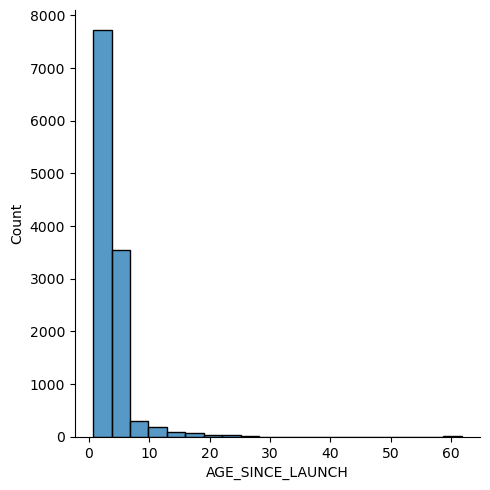

In [57]:
sns.displot(data=df, x = 'AGE_SINCE_LAUNCH', bins = 20)

In [58]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH
0,CALSPHERE 1,1964-063C,2025-10-05 10:37:28.191360,13.762289,0.002461,90.2163,65.8752,347.2003,74.9038,0,...,0.001091,1.074000e-05,0.0,6278.025279,7355.360594,984.360594,7337.256110,7373.465079,7.361506,61.761
1,CALSPHERE 2,1964-063E,2025-10-05 11:04:00.444864,13.528741,0.001678,90.2292,69.7816,244.2673,178.7129,0,...,0.000110,8.200000e-07,0.0,6386.403631,7439.769906,1068.769906,7427.284484,7452.255328,7.319626,61.761
3,TEMPSAT 1,1965-065E,2025-10-05 06:44:31.462944,13.335738,0.006776,89.9871,212.7305,243.9611,271.6250,0,...,0.000109,6.300000e-07,0.0,6478.831324,7511.379609,1140.379609,7460.481750,7562.277468,7.284652,60.761
4,CALSPHERE 4A,1965-065H,2025-10-05 13:13:59.657952,13.362208,0.007127,89.9109,124.8412,101.8063,291.1203,0,...,0.000297,1.650000e-06,0.0,6465.997033,7501.456514,1130.456514,7447.996634,7554.916394,7.289468,60.761
5,OPS 5712 (P/L 160),1967-053A,2025-10-05 11:22:39.247968,14.724473,0.000425,69.9186,300.3182,327.8826,32.2060,0,...,0.001667,1.053100e-04,0.0,5867.782237,7031.337118,660.337118,7028.346690,7034.327546,7.529215,58.761


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11990 entries, 0 to 12795
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   OBJECT_NAME          11990 non-null  object        
 1   OBJECT_ID            11990 non-null  object        
 2   EPOCH                11990 non-null  datetime64[ns]
 3   MEAN_MOTION          11990 non-null  float64       
 4   ECCENTRICITY         11990 non-null  float64       
 5   INCLINATION          11990 non-null  float64       
 6   RA_OF_ASC_NODE       11990 non-null  float64       
 7   ARG_OF_PERICENTER    11990 non-null  float64       
 8   MEAN_ANOMALY         11990 non-null  float64       
 9   EPHEMERIS_TYPE       11990 non-null  int64         
 10  CLASSIFICATION_TYPE  11990 non-null  object        
 11  NORAD_CAT_ID         11990 non-null  int64         
 12  ELEMENT_SET_NO       11990 non-null  int64         
 13  REV_AT_EPOCH         11990 non-null 

----
#### 5. Let's find what type of satellite part it it

In [60]:
# This information is stored as the last digit in the OBJECT_ID column
df['OBJECT_ID']

0        1964-063C
1        1964-063E
3        1965-065E
4        1965-065H
5        1967-053A
           ...    
12791    2025-220C
12792    2025-220D
12793    2025-220E
12794    2025-222A
12795    2025-222B
Name: OBJECT_ID, Length: 11990, dtype: object

In [61]:
# capture anything A-Z as a group
df['SAT_TYPE'] = df['OBJECT_ID'].str.extract(r'([A-Z])$')

In [62]:
df['SAT_TYPE'].value_counts()

SAT_TYPE
A    1142
B     830
C     763
D     673
E     635
F     544
G     512
H     509
J     491
K     477
L     457
M     442
N     430
R     414
P     413
Q     412
V     407
S     397
T     396
U     387
W     384
X     343
Y     298
Z     234
Name: count, dtype: int64

In [63]:
df.tail()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH,SAT_TYPE
12791,HULIANWANG DIGUI-84,2025-220C,2025-10-03 15:24:54.820224,13.690044,0.000828,86.4926,131.1986,194.1426,165.9503,0,...,6.600000e-07,0.0,6311.155973,7381.215260,1010.215260,7375.104352,7387.326168,7.348602,0.756,C
12792,HULIANWANG DIGUI-85,2025-220D,2025-10-03 15:23:56.942592,13.691724,0.000782,86.4982,131.2085,185.9250,174.1819,0,...,6.600000e-07,0.0,6310.381481,7380.611376,1009.611376,7374.840033,7386.382719,7.348902,0.756,D
12793,HULIANWANG DIGUI-86,2025-220E,2025-10-04 22:57:49.099392,13.692081,0.000762,86.4964,130.7257,181.6880,178.4255,0,...,6.600000e-07,0.0,6310.217008,7380.483130,1009.483130,7374.858464,7386.107796,7.348966,0.758,E
12794,SHIYAN-30 01,2025-222A,2025-10-05 12:35:11.259168,14.928145,0.000503,34.9899,350.2538,13.0573,347.0262,0,...,4.738000e-05,0.0,5787.725214,6967.236154,596.236154,6963.728848,6970.743461,7.563771,0.761,A
12795,SHIYAN-30 02,2025-222B,2025-10-05 12:34:10.183008,14.928032,0.000633,34.9984,350.2464,19.0025,341.0916,0,...,2.596000e-05,0.0,5787.768932,6967.271239,596.271239,6962.857473,6971.685006,7.563752,0.761,B


---
Correliation : (help up to check if according to physics our features are consistent (except anomalies!))

In [64]:
df.corr(numeric_only=True)

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH
MEAN_MOTION,1.000000,-0.135301,-0.341311,0.027659,0.124252,-0.127516,NaN,0.353654,NaN,-0.307187,0.009454,0.087546,0.028106,-0.998374,-0.998867,-0.998867,-0.993140,-0.993572,0.999817,-0.301113
ECCENTRICITY,-0.135301,1.000000,0.090278,-0.003990,-0.013116,0.010893,NaN,-0.162464,NaN,0.166749,0.006476,0.006108,0.002699,0.134506,0.134669,0.134669,0.028584,0.236241,-0.135087,0.200004
INCLINATION,-0.341311,0.090278,1.000000,0.097972,-0.230980,0.218979,NaN,-0.205410,NaN,0.221218,-0.059442,-0.066633,-0.006184,0.340530,0.340787,0.340787,0.334779,0.342919,-0.341255,0.215474
RA_OF_ASC_NODE,0.027659,-0.003990,0.097972,1.000000,-0.010886,-0.007596,NaN,0.031913,NaN,-0.015395,-0.067370,-0.086142,-0.021345,-0.028775,-0.028598,-0.028598,-0.028387,-0.028491,0.028045,-0.011471
ARG_OF_PERICENTER,0.124252,-0.013116,-0.230980,-0.010886,1.000000,-0.948901,NaN,0.157481,NaN,-0.131482,0.053950,0.088794,0.008536,-0.128127,-0.127540,-0.127540,-0.127211,-0.126474,0.125636,-0.087383
MEAN_ANOMALY,-0.127516,0.010893,0.218979,-0.007596,-0.948901,1.000000,NaN,-0.157311,NaN,0.132789,-0.006692,-0.059947,-0.008207,0.130051,0.129686,0.129686,0.129616,0.128345,-0.128452,0.081777
EPHEMERIS_TYPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NORAD_CAT_ID,0.353654,-0.162464,-0.205410,0.031913,0.157481,-0.157311,NaN,1.000000,NaN,-0.871563,-0.073937,-0.057539,-0.010944,-0.346399,-0.347628,-0.347628,-0.333687,-0.357390,0.351274,-0.869974
ELEMENT_SET_NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REV_AT_EPOCH,-0.307187,0.166749,0.221218,-0.015395,-0.131482,0.132789,NaN,-0.871563,NaN,1.000000,0.044199,0.025164,0.009288,0.299790,0.301016,0.301016,0.286143,0.312191,-0.304718,0.762175
